In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

conn = sqlite3.connect("../data/database.sqlite")

df_docs = pd.read_sql_query("SELECT * FROM documents", conn)
df_chunks = pd.read_sql_query("SELECT * FROM chunks", conn)

conn.close()

print(f"Nombre total de documents : {len(df_docs)}")
df_docs.head(3)

Nombre total de documents : 100


,id,titre,theme,public_cible,date_mise_a_jour,url_source
0,DOC_1,Texte encyclopédique n°1,Général / Encyclopédique,Tout public,2026-07-25 03:20:14.716866,HuggingFace: piaf
1,DOC_2,Texte encyclopédique n°2,Général / Encyclopédique,Tout public,2026-07-25 03:20:14.720663,HuggingFace: piaf
2,DOC_3,Texte encyclopédique n°3,Général / Encyclopédique,Tout public,2026-07-25 03:20:14.720746,HuggingFace: piaf


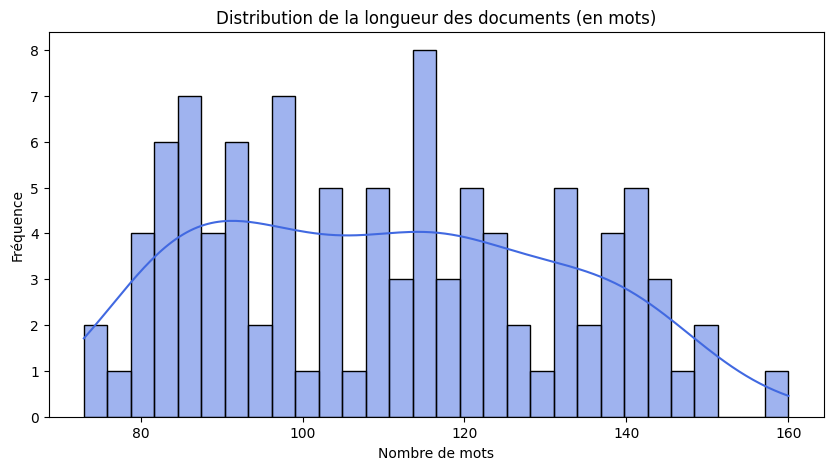

count    100.000000
mean     110.090000
std       21.565074
min       73.000000
25%       91.750000
50%      110.000000
75%      127.000000
max      160.000000
Name: word_count, dtype: float64


In [4]:
# Calcul du nombre de mots pour chaque texte
df_chunks['word_count'] = df_chunks['texte'].apply(lambda x: len(x.split()))

# Création du graphique
plt.figure(figsize=(10, 5))
sns.histplot(df_chunks['word_count'], bins=30, kde=True, color='royalblue')
plt.title("Distribution de la longueur des documents (en mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()


print(df_chunks['word_count'].describe())
